In [112]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"

data_1k = pd.read_csv(
    url_1k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_1k.columns = [
    "time",
    "dac",
    "shunt"
]

data_1k = data_1k.astype(float)

In [113]:
data_1k.head()

,time,dac,shunt
0,-1.85144,1.625156,0.002797
1,-1.85136,1.626406,0.002984
2,-1.85128,1.628437,0.002797
3,-1.85120,1.627500,0.001016
4,-1.85112,1.628906,0.003047


<Axes: xlabel='time'>

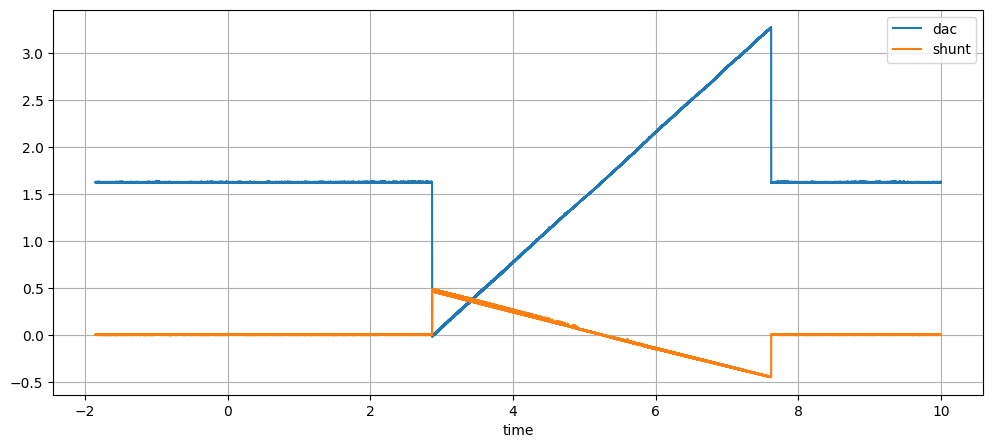

In [114]:
data_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

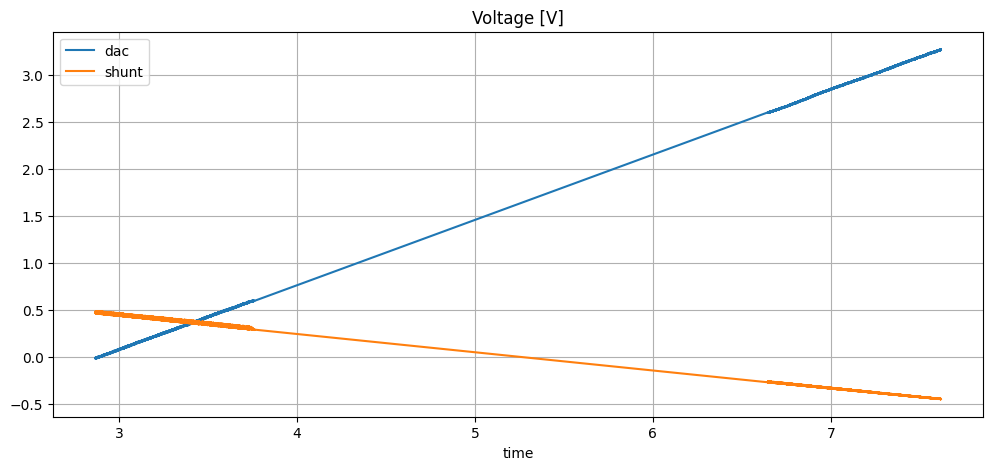

In [127]:
rest_value = 1.6
tolerance = 1

data_1k_linear = data_1k[
    (data_1k["dac"] < rest_value - tolerance) |
    (data_1k["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_1k_linear = data_1k_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_1k = data_1k_linear

data_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [121]:
data_1k["current"] = ( data_1k["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

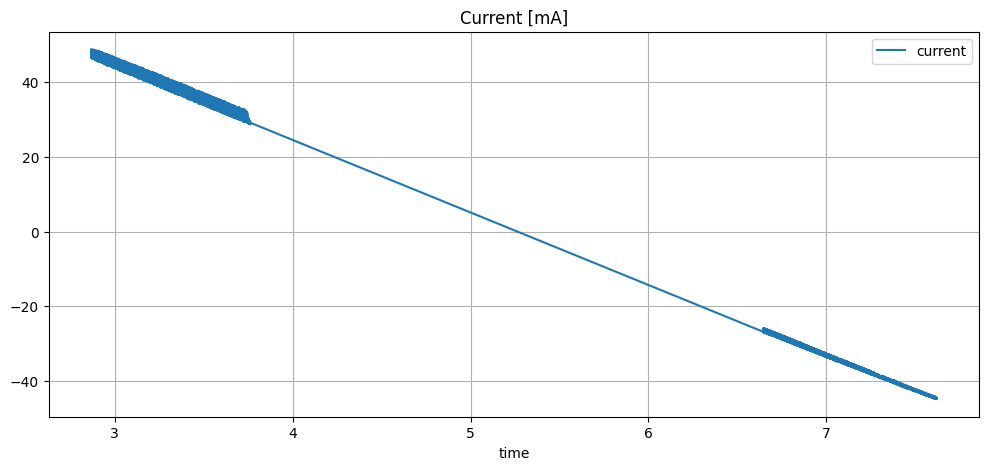

In [125]:
data_1k.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)